## LCA (H‑1B / H‑1B1 / E‑3) — FY2025 Q3 Analysis
This notebook analyzes the Labor Bureau's (Bureau of Labor Statistics) LCA data for fiscal year 2025 up to Q3, covering the period from **October 1, 2024 to June 30, 2025**.

Original Data: 
- Location: data/LCA_Disclosure_Data_FY2025_Q3.xlsx (due to github restrictions, please download from source and save to this location)
- Fast Read-in: data/LCA_Disclosure_Data_FY2025_Q3.parquet (please use xlsx_to_parquet.py to process and save as parquet file to this location)
- Source: https://www.dol.gov/agencies/eta/foreign-labor/performance 
- Detailed Explanation of Columns: data/LCA_Record_Layout_FY2025_Q3.pdf

## 0. Import & Settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)

In [3]:
# import utils
from lca_utils import *

In [4]:
import importlib, lca_utils
importlib.reload(lca_utils)

<module 'lca_utils' from 'c:\\Users\\elisa\\Desktop\\git\\codes\\data-analytics-portfolio\\LCA-Disclosure-Analysis\\lca_utils.py'>

In [5]:
# set up paths
MAIN_PATH = Path("data/LCA_Disclosure_Data_FY2025_Q3.xlsx")
PARQUET_PATH = Path("data/LCA_Disclosure_Data_FY2025_Q3.parquet")

In [6]:
# # preview data
# # main_preview = pd.read_excel(MAIN_PATH, nrows=10, dtype=str, engine="openpyxl")
# main_preview.head(10)

## 1. Read & Clean Data

In [7]:
# # read in excel
# main = pd.read_excel(MAIN_PATH, dtype=str, engine="openpyxl")

# # Column standardization
# main.columns = [c.strip().upper() for c in main.columns]

# # save as parquetFile
# for c in ["RECEIVED_DATE", "DECISION_DATE", "ORIGINAL_CERT_DATE", "BEGIN_DATE", "END_DATE"]:
#     if c in main.columns:
#         main[c] = pd.to_datetime(main[c], errors="coerce")

# main.to_parquet(PARQUET_PATH, engine="fastparquet", compression="snappy", index=False)
# print(f"Saved Parquet -> {PARQUET_PATH}")

In [8]:
# read from parquetFileRead for fast read
main = pd.read_parquet(PARQUET_PATH, engine="fastparquet")
main.head(5)

,CASE_NUMBER,CASE_STATUS,RECEIVED_DATE,DECISION_DATE,ORIGINAL_CERT_DATE,VISA_CLASS,JOB_TITLE,SOC_CODE,SOC_TITLE,FULL_TIME_POSITION,BEGIN_DATE,END_DATE,TOTAL_WORKER_POSITIONS,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,CHANGE_PREVIOUS_EMPLOYMENT,NEW_CONCURRENT_EMPLOYMENT,CHANGE_EMPLOYER,AMENDED_PETITION,EMPLOYER_NAME,TRADE_NAME_DBA,EMPLOYER_ADDRESS1,EMPLOYER_ADDRESS2,EMPLOYER_CITY,EMPLOYER_STATE,EMPLOYER_POSTAL_CODE,EMPLOYER_COUNTRY,EMPLOYER_PROVINCE,EMPLOYER_PHONE,EMPLOYER_PHONE_EXT,EMPLOYER_FEIN,NAICS_CODE,EMPLOYER_POC_LAST_NAME,EMPLOYER_POC_FIRST_NAME,EMPLOYER_POC_MIDDLE_NAME,EMPLOYER_POC_JOB_TITLE,EMPLOYER_POC_ADDRESS1,EMPLOYER_POC_ADDRESS2,EMPLOYER_POC_CITY,EMPLOYER_POC_STATE,EMPLOYER_POC_POSTAL_CODE,EMPLOYER_POC_COUNTRY,EMPLOYER_POC_PROVINCE,EMPLOYER_POC_PHONE,EMPLOYER_POC_PHONE_EXT,EMPLOYER_POC_EMAIL,AGENT_REPRESENTING_EMPLOYER,AGENT_ATTORNEY_LAST_NAME,AGENT_ATTORNEY_FIRST_NAME,AGENT_ATTORNEY_MIDDLE_NAME,AGENT_ATTORNEY_ADDRESS1,AGENT_ATTORNEY_ADDRESS2,AGENT_ATTORNEY_CITY,AGENT_ATTORNEY_STATE,AGENT_ATTORNEY_POSTAL_CODE,AGENT_ATTORNEY_COUNTRY,AGENT_ATTORNEY_PROVINCE,AGENT_ATTORNEY_PHONE,AGENT_ATTORNEY_PHONE_EXT,AGENT_ATTORNEY_EMAIL_ADDRESS,LAWFIRM_NAME_BUSINESS_NAME,STATE_OF_HIGHEST_COURT,NAME_OF_HIGHEST_STATE_COURT,WORKSITE_WORKERS,SECONDARY_ENTITY,SECONDARY_ENTITY_BUSINESS_NAME,WORKSITE_ADDRESS1,WORKSITE_ADDRESS2,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE,WAGE_RATE_OF_PAY_FROM,WAGE_RATE_OF_PAY_TO,WAGE_UNIT_OF_PAY,PREVAILING_WAGE,PW_UNIT_OF_PAY,PW_TRACKING_NUMBER,PW_WAGE_LEVEL,PW_OES_YEAR,PW_OTHER_SOURCE,PW_OTHER_YEAR,PW_SURVEY_PUBLISHER,PW_SURVEY_NAME,TOTAL_WORKSITE_LOCATIONS,AGREE_TO_LC_STATEMENT,H_1B_DEPENDENT,WILLFUL_VIOLATOR,SUPPORT_H1B,STATUTORY_BASIS,APPENDIX_A_ATTACHED,PUBLIC_DISCLOSURE,PREPARER_LAST_NAME,PREPARER_FIRST_NAME,PREPARER_MIDDLE_INITIAL,PREPARER_BUSINESS_NAME,PREPARER_EMAIL
0,I-200-25181-143446,Withdrawn,2025-06-30,2025-06-30,NaT,H-1B,Data Scientists,15-2051,Data Scientists,Y,2025-07-14,2028-07-13,1,0,0,0,0,1,0,"Urban Outfitters, Inc.",None,5000 South Broad Street,None,Philadelphia,PA,19112,UNITED STATES OF AMERICA,None,+12154544722,None,23-2003332,488190,Manning,Kristin,None,Manager of Global Mobility and Immigration,5000 South Broad Street,Suite 434,Philadelphia,PA,19112,UNITED STATES OF AMERICA,None,+12154544722,None,urbn@immigrationlaw.com,Yes,Yeaw,Jennifer,None,230 W. Monroe Street,Suite 2800,Chicago,IL,60606,UNITED STATES OF AMERICA,None,+13127226300,None,urbn@immigrationlaw.com,"Corporate Immigration Partners, P.C.",NC,Supreme Court,1,No,None,5000 South Broad Street,None,Philadelphia,PHILADELPHIA,PA,19112,175000,None,Year,136011,Year,None,IV,7/1/2024 - 6/30/2025,None,None,None,None,2,Yes,No,No,None,None,None,Disclose Business,Hashemi,Sophia,None,"Corporate Immigration Partners, P.C.",urbn@immigrationlaw.com
1,I-200-25181-141251,Withdrawn,2025-06-30,2025-06-30,NaT,H-1B,IT Technical Associate - Developer II,15-1242,Database Administrators,Y,2025-07-03,2028-07-02,1,1,0,0,0,0,0,Illinois Wesleyan University,None,1312 Park Street,None,Bloomington,IL,61702,UNITED STATES OF AMERICA,None,+13095561000,None,37-0662594,611310,FARLEY,Holly,None,Interim Provost and Vice President for Academi...,1301 - Ninth Street Hall,600 Lincoln Avenue,Charleston,IL,61920,UNITED STATES OF AMERICA,None,+12175817049,None,hrfarley@eiu.edu,Yes,Arkell,Thomas,J,"1001 North Main Street, Suite A",None,Bloomington,IL,61701,UNITED STATES OF AMERICA,None,+13098286241,None,admin@dunnlaw.com,"Dunn Law Firm, LLP",IL,Illinois Supreme Court,1,No,None,600 Lincoln Avenue,None,Charleston,COLES,IL,61938,54500,None,Year,50877,Year,None,I,7/1/2024 - 6/30/2025,None,None,None,None,1,Yes,No,No,None,None,None,Disclose Business,None,None,None,None,None
2,I-200-25181-142198,Withdrawn,2025-06-30,2025-06-30,NaT,H-1B,Research Associate,19-1021,Biochemists and Biophysicists,Y,2025-09-08,2026-09-07,1,1,0,0,0,0,0,TRUSTEES OF THE UNIVERSITY OF PENNSYLVANIA,UNIVERSITY OF PENNSYLVANIA,3935 Walnut Street,5th Floor,PHILADELPHIA,PA,19104,UNITED STA

In [9]:
# add computed annual wage Column
main = add_offered_wage_annual(main,
                               auto_annual_from_threshold=50000)

In [10]:
# filter computed wage outliers
main = filter_wage_outliers(main)

In [11]:
main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 478013 entries, 0 to 479004
Data columns (total 98 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   CASE_NUMBER                     478013 non-null  object        
 1   CASE_STATUS                     478013 non-null  object        
 2   RECEIVED_DATE                   478013 non-null  datetime64[ns]
 3   DECISION_DATE                   478013 non-null  datetime64[ns]
 4   ORIGINAL_CERT_DATE              21947 non-null   datetime64[ns]
 5   VISA_CLASS                      478013 non-null  object        
 6   JOB_TITLE                       478013 non-null  object        
 7   SOC_CODE                        478013 non-null  object        
 8   SOC_TITLE                       478013 non-null  object        
 9   FULL_TIME_POSITION              478013 non-null  object        
 10  BEGIN_DATE                      478013 non-null  datetime64[n

## 2. Analysis & Visualization

### 2.1 Overall

#### application count
From fiscal year 2025 to date, a total of 478,013 applications were received, involving 782,167 beneficiaries.

In [12]:
# Total Applications Count
total_cases = main['CASE_NUMBER'].nunique()
print(f"Total number of cases submited: {total_cases}")

# Total beneficiaries Count
print(f"Total positions applied: {main['TOTAL_WORKER_POSITIONS'].astype(int).sum()}")

Total number of cases submited: 478013
Total positions applied: 782167


#### monthly count
The number of applications rose rapidly from March, peaking in May and June (corresponding to the announcement of the H1B lottery results that year).

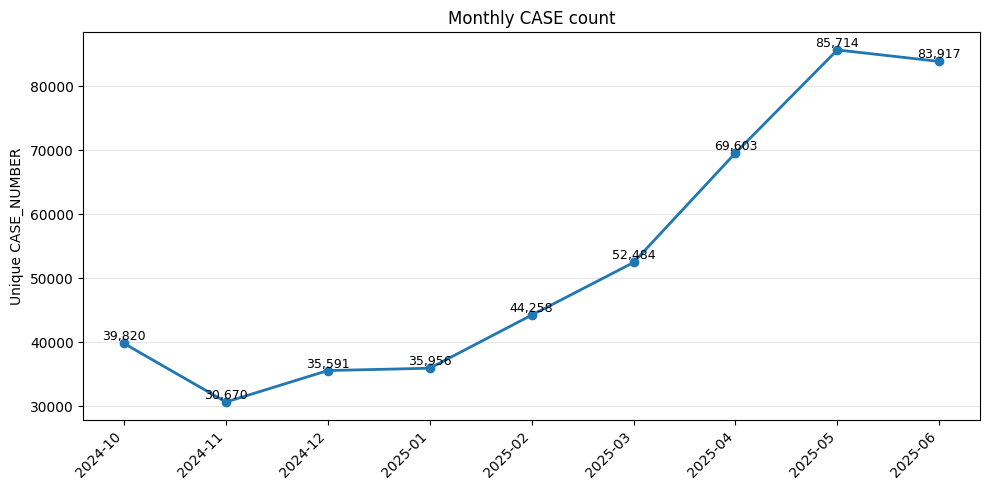

,CASE_COUNT
DECISION_MONTH,
2024-10,39820
2024-11,30670
2024-12,35591
2025-01,35956
2025-02,44258
2025-03,52484
2025-04,69603
2025-05,85714
2025-06,83917


In [ ]:
# Applications Count by month
plot_line_monthly_cases(main)

#### case status
The approval rate for applications is close to 98%, but about 4.5% of these applications are withdrawn, possibly due to candidates submitting multiple applications.

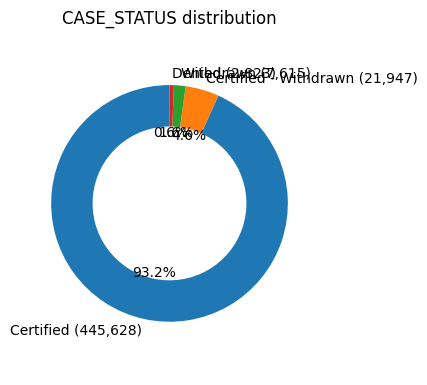

,count,pct
CASE_STATUS,,
Certified,445628,93.23
Certified - Withdrawn,21947,4.59
Withdrawn,7615,1.59
Denied,2823,0.59


In [14]:
# Application Status Distribution
plot_donut_from_counts(main["CASE_STATUS"].value_counts(), 
                       title="CASE_STATUS distribution")

#### visa class
Overall, nearly 98% are H-1B visas, with the remainder being special work visas from Australia, Chile, and Singapore (E3/H1B1).

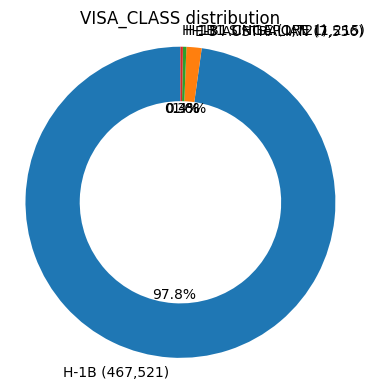

,count,pct
VISA_CLASS,,
H-1B,467521,97.81
E-3 AUSTRALIAN,7556,1.58
H-1B1 CHILE,1721,0.36
H-1B1 SINGAPORE,1215,0.25


In [13]:
# visa class distribution
plot_donut_from_counts(main["VISA_CLASS"].astype(str).str.upper().value_counts(), 
                       title="VISA_CLASS distribution")

#### SOC title
- In terms of standardized job postings, Software Developers account for over 30%, a significant lead over the next few.

- Apart from Accountants and Auditors (ranked 10th), the rest of the top 10 are all Computer/Software/Data related.

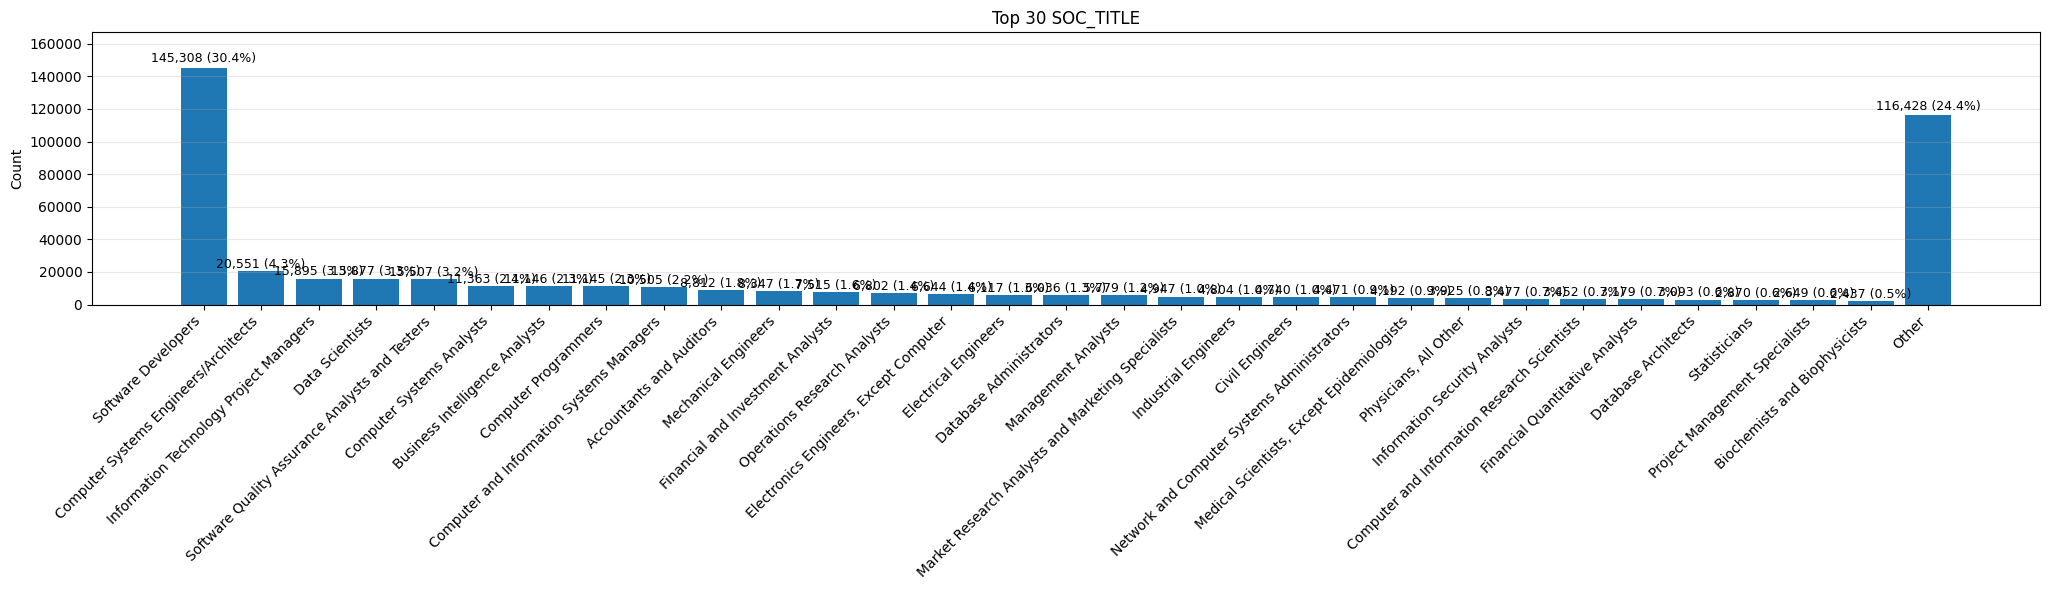

,count,pct
SOC_TITLE,,
Software Developers,145308,30.4
Computer Systems Engineers/Architects,20551,4.3
Information Technology Project Managers,15895,3.3
Data Scientists,15877,3.3
Software Quality Assurance Analysts and Testers,15507,3.2
Computer Systems Analysts,11363,2.4
Business Intelligence Analysts,11146,2.3
Computer Programmers,11145,2.3
Computer and Information Systems Managers,10505,2.2


In [ ]:
# SOC_TITLE (Standardized Job Title) Distribution, Bar Chart
plot_bar_counts_vertical_simple(main["SOC_TITLE"], 
                                top_n=30, 
                                title="Top 30 SOC_TITLE")

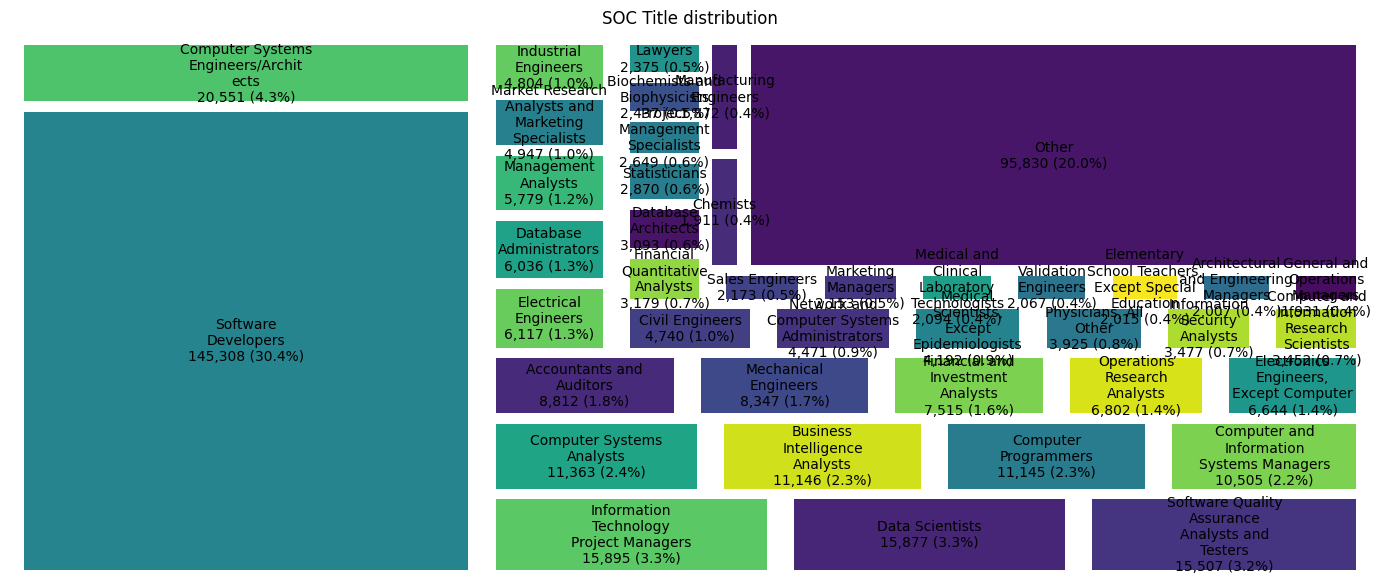

,count,pct
SOC_TITLE,,
Software Developers,145308,30.4
Computer Systems Engineers/Architects,20551,4.3
Information Technology Project Managers,15895,3.3
Data Scientists,15877,3.3
Software Quality Assurance Analysts and Testers,15507,3.2
Computer Systems Analysts,11363,2.4
Business Intelligence Analysts,11146,2.3
Computer Programmers,11145,2.3
Computer and Information Systems Managers,10505,2.2


In [14]:
# SOC_TITLE (Standardized Job Title) Distribution, treemap
plot_treemap_from_series(main["SOC_TITLE"], top_n=40, title="SOC Title distribution")

#### full-time
Over 98% of the applications are for full-time positions.

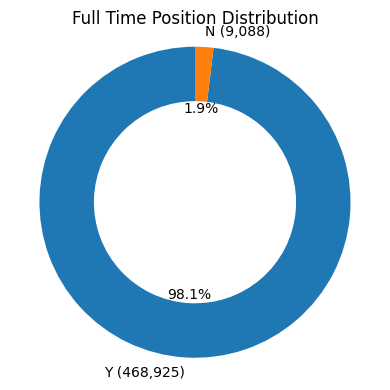

,count,pct
FULL_TIME_POSITION,,
Y,468925,98.1
N,9088,1.9


In [15]:
# is full time or not
plot_donut_from_counts(main['FULL_TIME_POSITION'].value_counts(), 
                       title='Full Time Position Distribution')

#### total workers
- Approximately 95.5% of applications include only one beneficiary.

- There are cases where one application corresponds to a large number of beneficiaries.

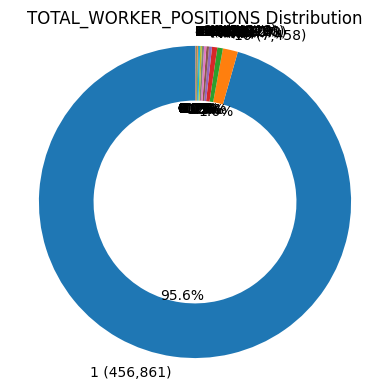

,count,pct
TOTAL_WORKER_POSITIONS,,
1,456861,95.58
10,7458,1.56
5,2748,0.57
3,2607,0.55
40,1476,0.31
2,1282,0.27
25,1129,0.24
20,1046,0.22
50,823,0.17


In [19]:
# case对应的职位Count分布
plot_donut_from_counts(main['TOTAL_WORKER_POSITIONS'].value_counts(), 
                       title='TOTAL_WORKER_POSITIONS Distribution')

#### application category
In terms of application category distribution:

- NEW_EMPLOYMENT: This indicates the beneficiary will begin working for a new employer, accounting for **38.2%**.

- CONTINUED_EMPLOYMENT: This indicates the beneficiary will continue working for the same employer, accounting for **26.2%**.

- AMENDED_EMPLOYMENT: This indicates the beneficiary will be continuing employment with same employer with material change to job duties, accounting for **16.4%**.

- CHANGE_EMPLOYER: This indicates the beneficiary will begin employment for new employer, using the same classification currently held, accounting for **15.5%**.

- CHANGE_PREVIOUS_EMPLOYMENT: This indicates the beneficiary will be continuing employment with same employer without material change to job duties. This category accounts for **8.2%**.

- NEW_CONCURRENT_EMPLOYMENT: This indicates the beneficiary will begin employment with an additional employer. This category accounts for **0.5%**.

Note: Please refer to data/LCA_Record_Layout_FY2025_Q3.pdf for the definitions of each category.

,variable,nonzero_count,total_rows,pct_nonzero
0,NEW_EMPLOYMENT,182788,478013,38.2
1,CONTINUED_EMPLOYMENT,125412,478013,26.2
2,AMENDED_PETITION,78620,478013,16.4
3,CHANGE_EMPLOYER,74167,478013,15.5
4,CHANGE_PREVIOUS_EMPLOYMENT,39194,478013,8.2
5,NEW_CONCURRENT_EMPLOYMENT,2350,478013,0.5


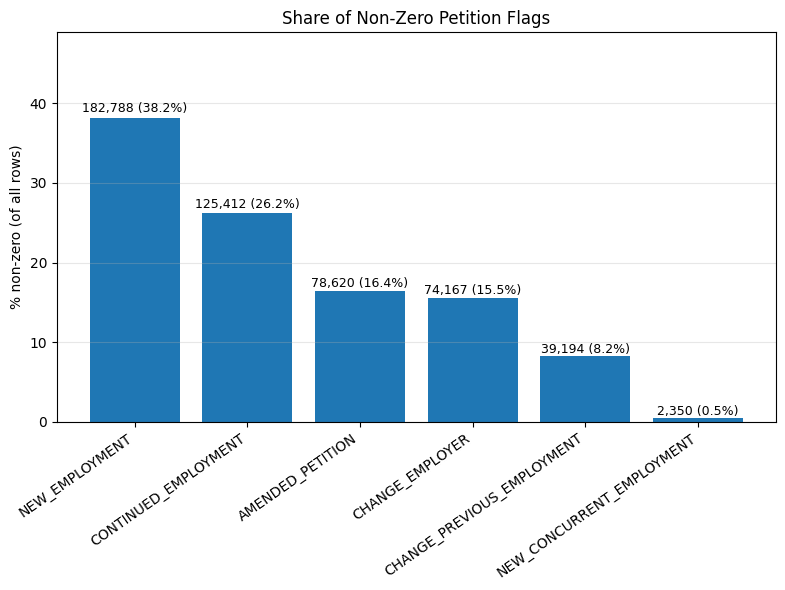

In [ ]:
# Petition flags non-zero share
flags = ["NEW_EMPLOYMENT",
         "CONTINUED_EMPLOYMENT",
         "CHANGE_PREVIOUS_EMPLOYMENT",
         "NEW_CONCURRENT_EMPLOYMENT",
         "CHANGE_EMPLOYER",
         "AMENDED_PETITION"]

res_flags = nonzero_share(main, flags)
display(res_flags)
plot_nonzero_share_vertical(res_flags, title="Share of Non-Zero Petition Flags")

#### employer
- The top 40 employers by application volume account for approximately 25% of all applications.

- The employers with the most applications include: Amazon, E&Y, Cognizant, Google, Microsoft, Meta, Apply, Infosys, Tata, and Walmart.

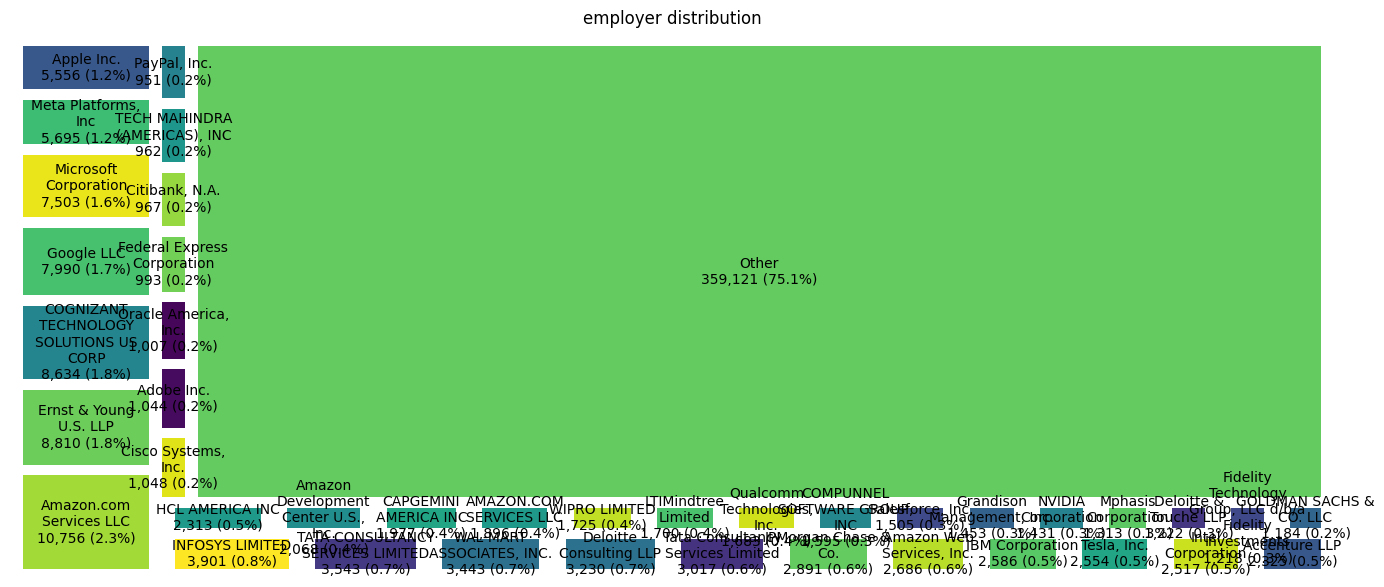

,count,pct
EMPLOYER_NAME,,
Amazon.com Services LLC,10756,2.3
Ernst & Young U.S. LLP,8810,1.8
COGNIZANT TECHNOLOGY SOLUTIONS US CORP,8634,1.8
Google LLC,7990,1.7
Microsoft Corporation,7503,1.6
"Meta Platforms, Inc",5695,1.2
Apple Inc.,5556,1.2
INFOSYS LIMITED,3901,0.8
TATA CONSULTANCY SERVICES LIMITED,3543,0.7


In [16]:
# employer distribution
plot_treemap_from_series(main["EMPLOYER_NAME"], 
                         top_n=40, 
                         title="employer distribution")

#### employer state
In terms of employer location, the highest percentages are in California (20.4%), Texas (11.8%), New Jersey (9.1%), New York (7.9%), and Washington (6.2%).

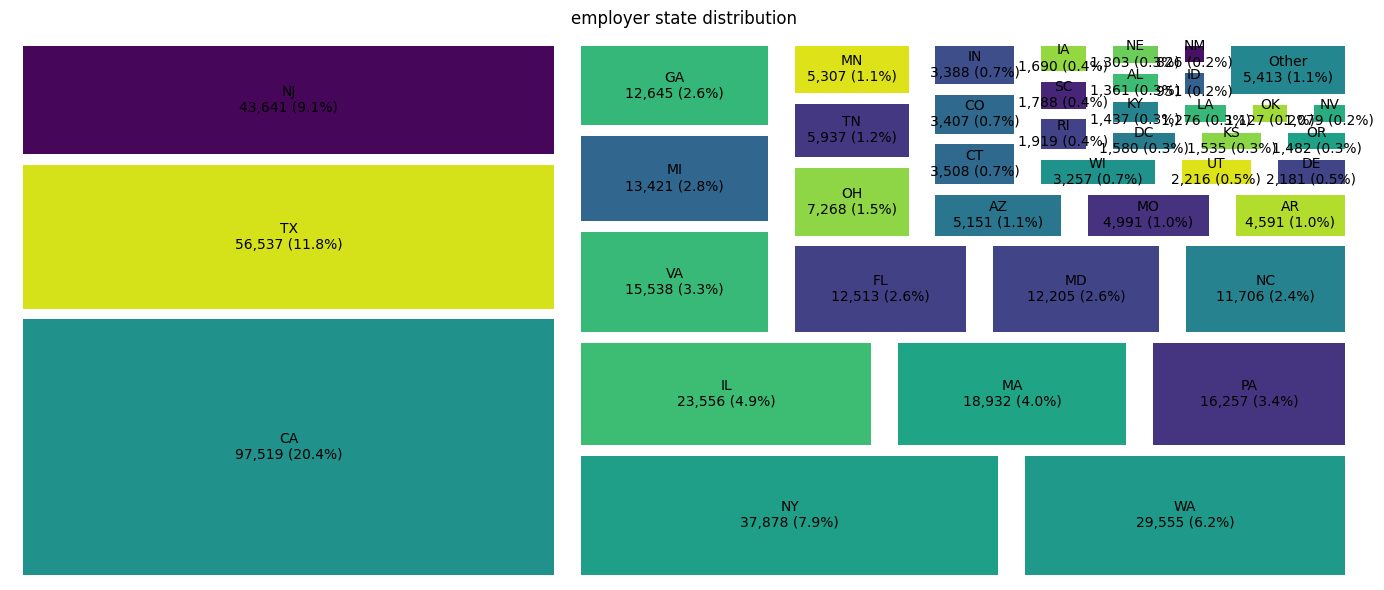

,count,pct
EMPLOYER_STATE,,
CA,97519,20.4
TX,56537,11.8
NJ,43641,9.1
NY,37878,7.9
WA,29555,6.2
IL,23556,4.9
MA,18932,4.0
PA,16257,3.4
VA,15538,3.3


In [ ]:
# employer state
plot_treemap_from_series(main["EMPLOYER_STATE"], 
                         top_n=40, 
                         title="employer state distribution")

#### worksite state
Looking at the distribution of beneficiaries' actual work states, the differences are not significant compared to the employers' states, but the rankings have changed: California 18.8%, Texas 15%, New York 8.5%, Washington 6.1%, and New Jersey 4.9%.

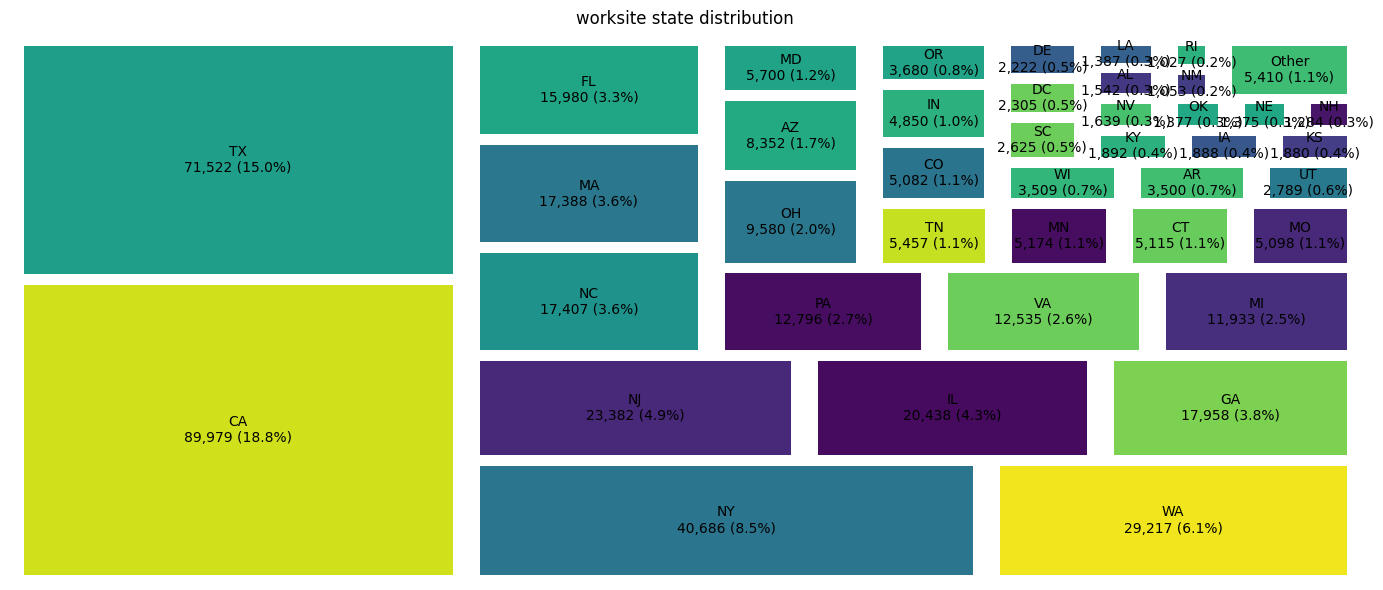

,count,pct
WORKSITE_STATE,,
CA,89979,18.8
TX,71522,15.0
NY,40686,8.5
WA,29217,6.1
NJ,23382,4.9
IL,20438,4.3
GA,17958,3.8
NC,17407,3.6
MA,17388,3.6


In [ ]:
# worksite state
plot_treemap_from_series(main["WORKSITE_STATE"], 
                         top_n=40, 
                         title="worksite state distribution")

#### annual wage
Looking at the salary distribution after the cleanup, the average is 128K, the median is 118K, and over 90% of applicants have a salary of less than 200K.

In [ ]:
# Year Wage Distribution, percentiles
deciles(series=main["OFFERED_WAGE_ANNUAL_USD"].dropna().astype(float),
        step=0.1)

,percentile,value
0,0,15080.04
1,10,71947.00
2,20,84094.00
3,30,95000.00
4,40,105997.00
5,50,117832.00
6,60,130000.00
7,70,146307.20
8,80,165322.66
9,90,195539.80


In [25]:
main['OFFERED_WAGE_ANNUAL_USD'].describe()

count    4.780130e+05
mean     1.288371e+05
std      7.312493e+04
min      1.508004e+04
25%      8.975000e+04
50%      1.178320e+05
75%      1.546160e+05
max      2.130000e+07
Name: OFFERED_WAGE_ANNUAL_USD, dtype: float64

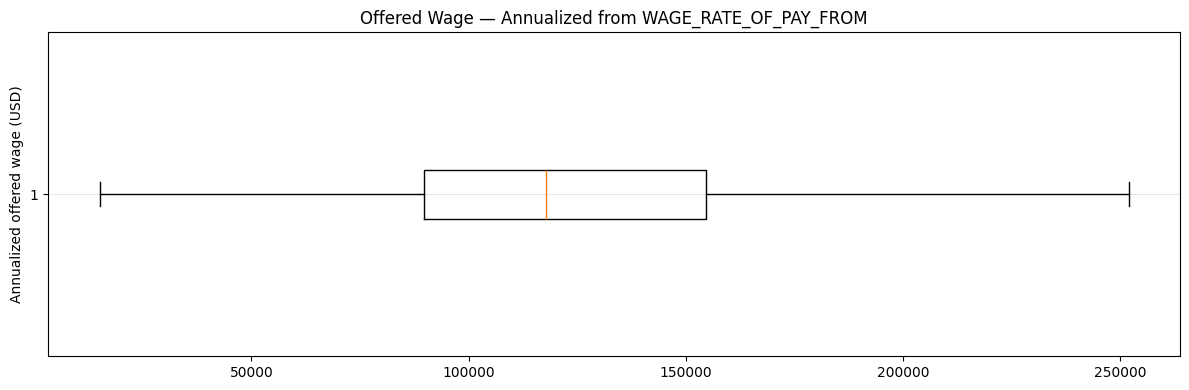

In [ ]:
# Boxplot wage
plt.figure(figsize=(12, 4))
plt.boxplot(main['OFFERED_WAGE_ANNUAL_USD'], vert=False, showfliers=False)
plt.ylabel("Annualized offered wage (USD)")
plt.title("Offered Wage — Annualized from WAGE_RATE_OF_PAY_FROM")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

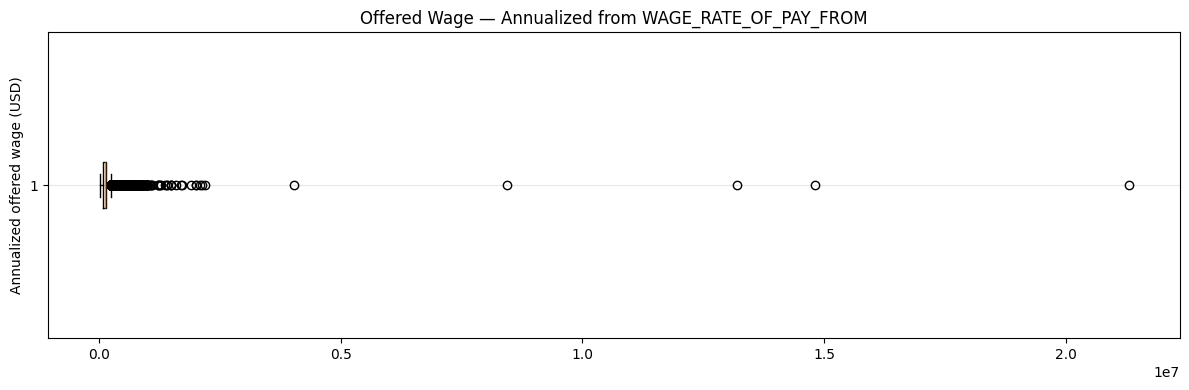

In [ ]:
# Boxplot wage , including outliers
plt.figure(figsize=(12, 4))
plt.boxplot(main['OFFERED_WAGE_ANNUAL_USD'], vert=False, showfliers=True)
plt.ylabel("Annualized offered wage (USD)")
plt.title("Offered Wage — Annualized from WAGE_RATE_OF_PAY_FROM")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### wage by title
Looking at job categories with over 500 applications, the categories with the highest median salaries are: Hospitalists, Physicians, Chief Executives, Lawyers, and Computer and Info Systems; while the categories with the lowest median salaries are: Rehabilitation Counselors, Biological Technicians, Secondary School Teachers, Middle School Teachers, and Elementary School Teachers.

In [17]:
# SOC title Categories with top10/bottom10 median salaries
top10, bot10 = soc_median_tables(main, 
                                 wage_col="OFFERED_WAGE_ANNUAL_USD", 
                                 soc_col="SOC_TITLE", 
                                 min_count=500)
display(top10)
display(bot10)

,SOC_TITLE,n,median_annual
444,Hospitalists,1389,278012.80
400,General Internal Medicine Physicians,1095,240178.00
143,Chief Executives,743,229000.00
495,Lawyers,2375,225000.00
208,Computer and Information Systems Managers,10505,195000.00
357,Financial Managers,1399,190756.80
205,Computer and Information Research Scientists,3452,181030.00
261,"Dentists, General",847,180000.00
55,Architectural and Engineering Managers,2007,178000.00
529,Marketing Managers,2153,170605.24


,SOC_TITLE,n,median_annual
726,Rehabilitation Counselors,532,39145.6
99,Biological Technicians,799,55806.0
762,"Secondary School Teachers, Except Special and ...",1785,57238.0
570,"Middle School Teachers, Except Special and Car...",840,57460.0
313,"Elementary School Teachers, Except Special Edu...",2015,59878.0
563,Mental Health Counselors,531,65000.0
560,Medical and Clinical Laboratory Technologists,2094,66123.2
702,Public Relations Specialists,590,66530.0
113,"Business Operations Specialists, All Other",515,68296.0
608,Occupational Therapists,817,71968.0


#### h1b dependent
5,253 companies have explicitly stated that they rely on H-1B visas, and they submitted almost one quarter of total applications.

In [35]:
depend_list = main[main['H_1B_DEPENDENT']=='Yes']['EMPLOYER_NAME'].unique().tolist()
print(f"# of companies that specifically depends on H1b: {len(depend_list)}")
print(depend_list[:20])

# of companies that specifically depends on H1b: 5253
['TATA CONSULTANCY SERVICES LIMITED', 'INFOTECH PRISM LLC', 'Bean Infosystems LLC', 'Radixlink, Inc.', 'IndSoft, Inc.', 'Apogee Medical Group, Delaware, Inc.', 'Neni TechSystems Inc ', 'RITE PROS, INC', 'COGNIZANT TECHNOLOGY SOLUTIONS US CORP', 'Mphasis Corporation', 'Prodapt North America, Inc.', 'Capgemini America Inc', 'Intone Networks, Inc.', 'Tata Consultancy Services Limited', 'Tekgroup LLC', 'Mphasis Corporation ', 'SERVESYS CORPORATION', 'Advanced Micro Devices, Inc.', 'IGATE Solutions LLC', 'Meta Platforms, Inc']


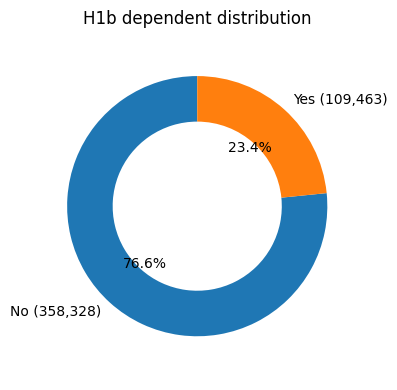

,count,pct
H_1B_DEPENDENT,,
No,358328,76.6
Yes,109463,23.4


In [34]:
plot_donut_from_counts(main['H_1B_DEPENDENT'].value_counts(), 
                       title='H1b dependent distribution')

#### sponsor h1b
5,188 companies have explicitly stated that they support H-1B visas.

In [36]:
support_list = main[main['SUPPORT_H1B']=='Yes']['EMPLOYER_NAME'].unique().tolist()
print(f"# of companies that specifically support H1b: {len(support_list)}")
print(support_list[:20])

# of companies that specifically support H1b: 5188
['TATA CONSULTANCY SERVICES LIMITED', 'INFOTECH PRISM LLC', 'Bean Infosystems LLC', 'Radixlink, Inc.', 'IndSoft, Inc.', 'Apogee Medical Group, Delaware, Inc.', 'Neni TechSystems Inc ', 'RITE PROS, INC', 'COGNIZANT TECHNOLOGY SOLUTIONS US CORP', 'Mphasis Corporation', 'Prodapt North America, Inc.', 'Capgemini America Inc', 'Intone Networks, Inc.', 'Tata Consultancy Services Limited', 'Tekgroup LLC', 'Mphasis Corporation ', 'SERVESYS CORPORATION', 'Advanced Micro Devices, Inc.', 'IGATE Solutions LLC', 'Meta Platforms, Inc']


### 2.2 Among Data Positions

#### filter
In below section, I'll analyze the data-related positions that I'm most interested in. First, I filtered my target positions — data scientist, data analyst, and business analyst, using two fields: SOC title and input job title.

In [18]:
# Filter Data positions
# 1) SOC_TITLE match 
soc_targets = {s.casefold() for s in ["Data Scientists", "Business Intelligence Analysts"]}
mask_soc = main["SOC_TITLE"].astype(str).str.strip().str.casefold().isin(soc_targets)

# 2) JOB_TITLE match 
keywords = [
    "Data Analyst",
    "Data Scientist",
    "Data Science",
    "Business Analyst",
    "Data Analytics",
    "Advanced Analytics",
]
pattern = "|".join(re.escape(k) for k in keywords)
mask_job = main["JOB_TITLE"].astype(str).str.contains(pattern, case=False, na=False)

# 3) Merge
data_subset = main[mask_soc | mask_job].copy()

#### application count
From fiscal year 2025 to date, the number of applications for data-related positions is 33,419 (accounting for 7% of the total), with a total of 50,632 beneficiaries.

In [19]:
# Number of applications for Data-related positions 
total_cases = data_subset['CASE_NUMBER'].nunique() 
print(f"Total number of cases submitted: {total_cases}")

# Number of positions corresponding to each Data-related case 
print(f"Total positions applied: {data_subset['TOTAL_WORKER_POSITIONS'].astype(int).sum()}")

Total number of cases submitted: 33419
Total positions applied: 50632


#### monthly count
Generally, the interview process can take 1-3 months, with 2 months being the most common. This indicates that data related recruitment was relatively slow in the second half of 2024, only accelerating in January 2025, peaking in March-April 2025.

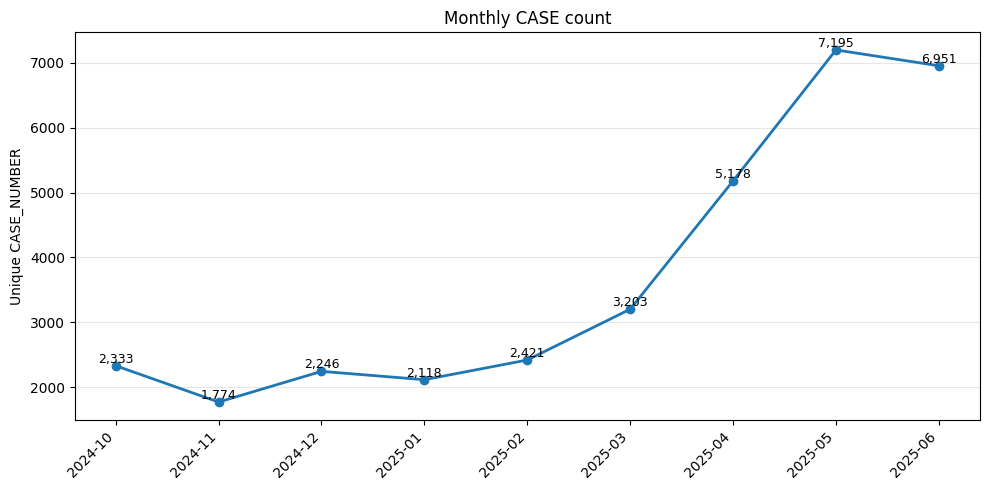

,CASE_COUNT
DECISION_MONTH,
2024-10,2333
2024-11,1774
2024-12,2246
2025-01,2118
2025-02,2421
2025-03,3203
2025-04,5178
2025-05,7195
2025-06,6951


In [20]:
# Applications Count for Data-related positions, by month
plot_line_monthly_cases(data_subset)

#### case status
For Data positions, approximately 98% of applications are approved; compared to the overall rate, fewer applications are withdrawn.

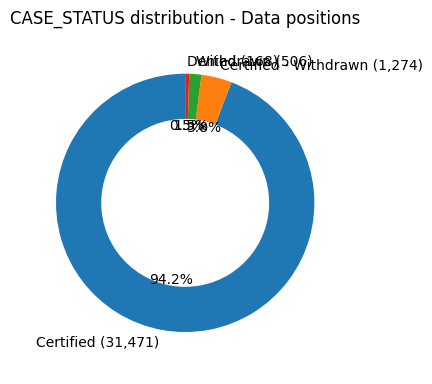

,count,pct
CASE_STATUS,,
Certified,31471,94.17
Certified - Withdrawn,1274,3.81
Withdrawn,506,1.51
Denied,168,0.50


In [ ]:
# case status
plot_donut_from_counts(data_subset["CASE_STATUS"].value_counts(), 
                       title="CASE_STATUS distribution - Data positions")

#### visa class
Over 99% of data-related applications are under the H-1B visa category, higher than the overall percentage of less than 98%, indicating that data-related positions rely more heavily on the H-1B visa.

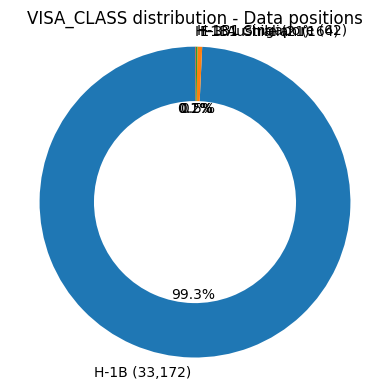

,count,pct
VISA_CLASS,,
H-1B,33172,99.26
E-3 Australian,164,0.49
H-1B1 Singapore,62,0.19
H-1B1 Chile,21,0.06


In [ ]:
# visa class
plot_donut_from_counts(data_subset["VISA_CLASS"].value_counts(), 
                       title="VISA_CLASS distribution - Data positions")

#### application category
Looking at the application category distribution for Data positions:

- NEW_EMPLOYMENT: This indicates the applicant will begin working for a new employer, accounting for 44.6%, higher than the overall 38.2%.

- CONTINUED_EMPLOYMENT: This indicates the applicant will continue working for the same employer, accounting for 21.3%, lower than the overall 26.2%.

- AMENDED_EMPLOYMENT: This indicates the applicant will be continuing employment with same employer with material change to job duties, accounting for 13.3%, slightly lower than the overall.

- CHANGE_EMPLOYER: This indicates the applicant will begin employment for new employer, using the same classification currently held, accounting for 16.7%, higher than the overall 15.5%.

- CHANGE_PREVIOUS_EMPLOYMENT: is 7.4%, this indicates requested worker(s) will be continuing employment with same employer without material change to job dutie, lower than the overall percentage of 8.2%.

- NEW_CONCURRENT_EMPLOYMENT is 0.3%

,variable,nonzero_count,total_rows,pct_nonzero
0,NEW_EMPLOYMENT,14895,33419,44.6
1,CONTINUED_EMPLOYMENT,7104,33419,21.3
2,CHANGE_EMPLOYER,5595,33419,16.7
3,AMENDED_PETITION,4437,33419,13.3
4,CHANGE_PREVIOUS_EMPLOYMENT,2460,33419,7.4
5,NEW_CONCURRENT_EMPLOYMENT,103,33419,0.3


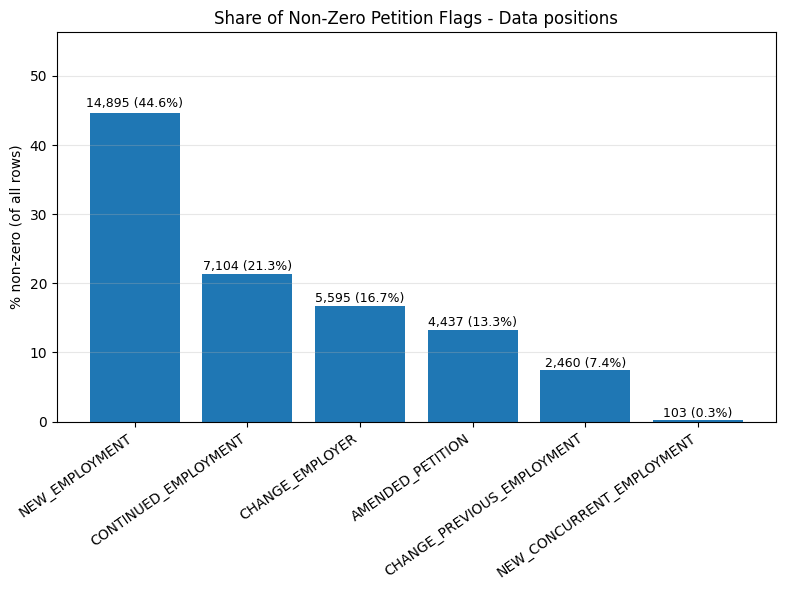

In [21]:
# Petition flags non-zero Share
flags = ["NEW_EMPLOYMENT",
         "CONTINUED_EMPLOYMENT",
         "CHANGE_PREVIOUS_EMPLOYMENT",
         "NEW_CONCURRENT_EMPLOYMENT",
         "CHANGE_EMPLOYER",
         "AMENDED_PETITION"]

res_flags = nonzero_share(data_subset, flags)
display(res_flags)
plot_nonzero_share_vertical(res_flags, 
                            title="Share of Non-Zero Petition Flags - Data positions")

#### employer
- The employer distribution for data positions is similar to the overall distribution, with the top 40 employers accounting for over 25% of applications. 
- In terms of employer rankings, Walmart, JPMorgan Chase, and Capital One significantly rank higher than the overall ranking.

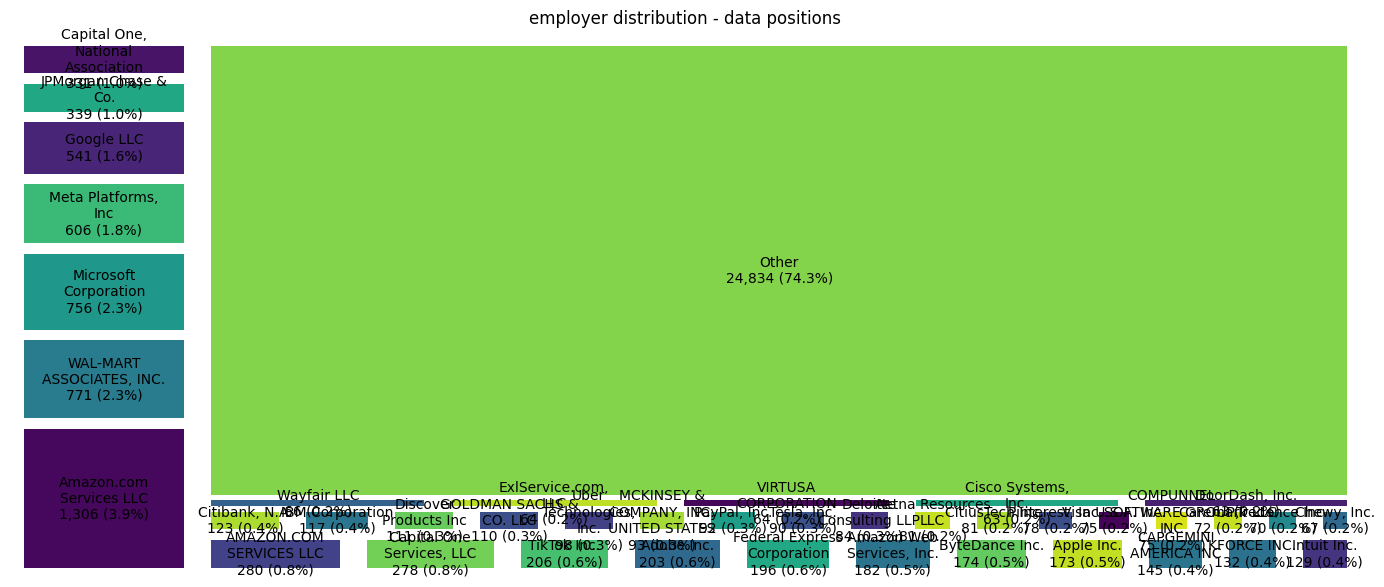

,count,pct
EMPLOYER_NAME,,
Amazon.com Services LLC,1306,3.9
"WAL-MART ASSOCIATES, INC.",771,2.3
Microsoft Corporation,756,2.3
"Meta Platforms, Inc",606,1.8
Google LLC,541,1.6
JPMorgan Chase & Co.,339,1.0
"Capital One, National Association",331,1.0
AMAZON.COM SERVICES LLC,280,0.8
"Capital One Services, LLC",278,0.8


In [ ]:
# Data-related positions Employer Distribution
plot_treemap_from_series(data_subset["EMPLOYER_NAME"], 
                         top_n=40, title="employer distribution - data positions")

#### employer state
Looking at the distribution of employers for data-related positions by state, the highest percentages are in California (20.7%), Texas (9.2%), New York (8.5%), Washington (8.4%), and New Jersey (7.4%). Washington is higher than the overall average, while New Jersey and Texas are lower.

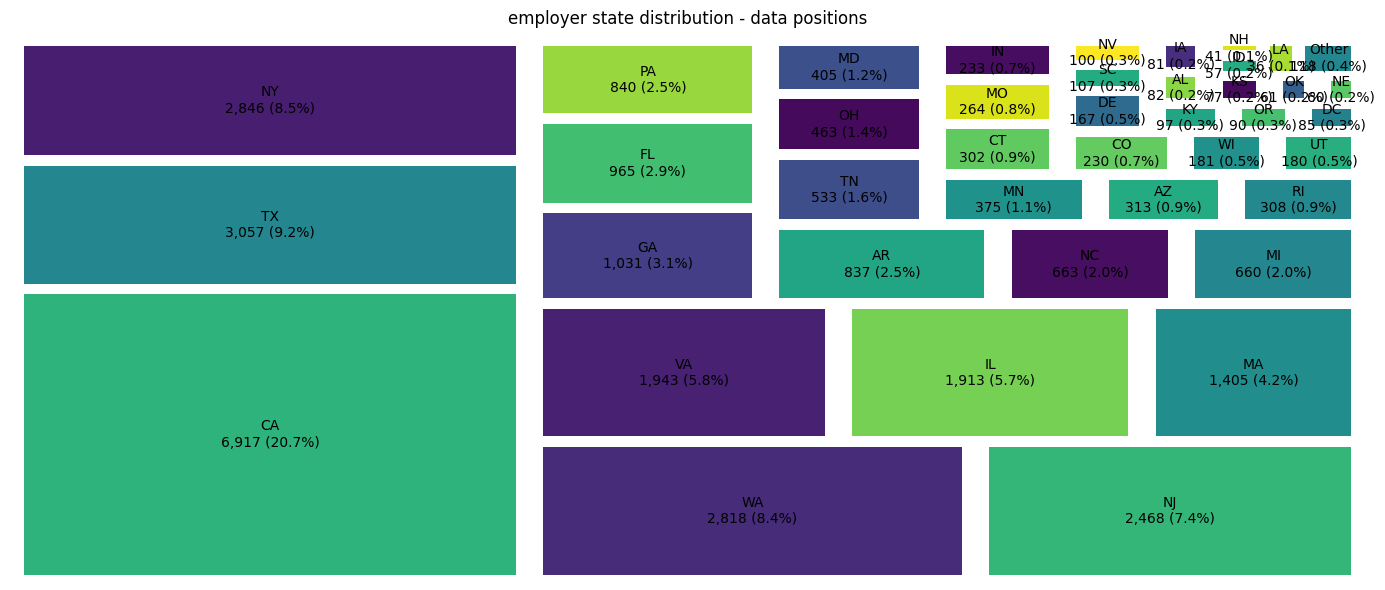

,count,pct
EMPLOYER_STATE,,
CA,6917,20.7
TX,3057,9.2
NY,2846,8.5
WA,2818,8.4
NJ,2468,7.4
VA,1943,5.8
IL,1913,5.7
MA,1405,4.2
GA,1031,3.1


In [22]:
# Data-related positions Employer state Distribution
plot_treemap_from_series(data_subset["EMPLOYER_STATE"], 
                               top_n=40, title="employer state distribution - data positions")

#### worksite state
Looking at the distribution of beneficiaries in data-related positions by their actual work state, the rankings are consistent with those of their employers' states, but Texas is higher and New Jersey is lower: California 19.2%, Texas 14.2%, New York 9.4%, Washington 8.4%, and New Jersey 6.1%.

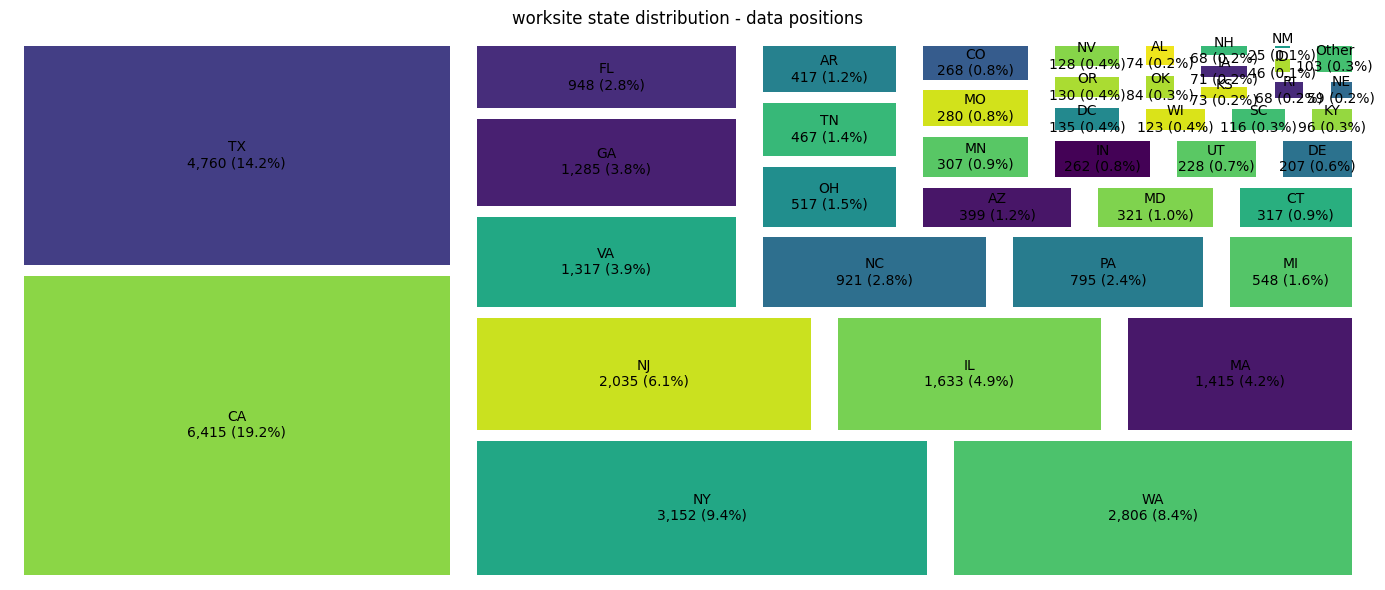

,count,pct
WORKSITE_STATE,,
CA,6415,19.2
TX,4760,14.2
NY,3152,9.4
WA,2806,8.4
NJ,2035,6.1
IL,1633,4.9
MA,1415,4.2
VA,1317,3.9
GA,1285,3.8


In [23]:
# Data-related positions worksite state Distribution
plot_treemap_from_series(data_subset["WORKSITE_STATE"], 
                         top_n=40, title="worksite state distribution - data positions")

#### wage by title
Looking at the salary distribution for the three data roles, data scientists earn the most, with a median of $126,000, while data analysts earn the least, with a median of only $97,000, and business analysts earn $111,000.

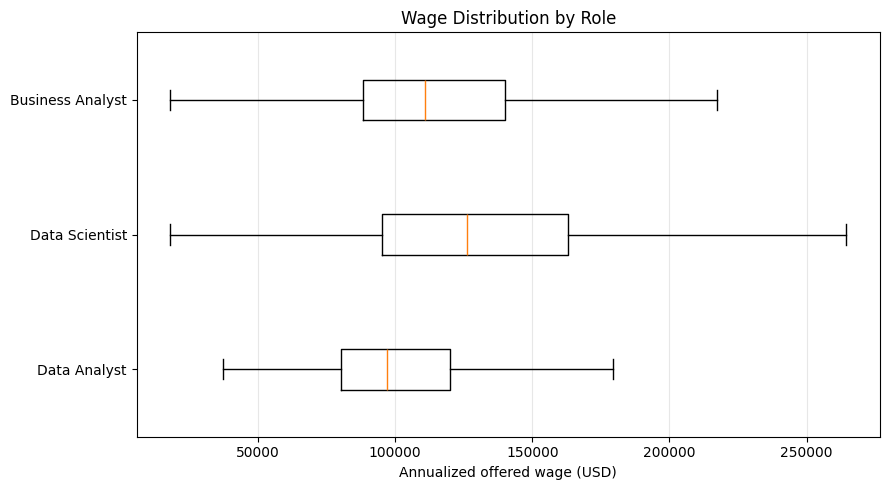

,Data Analyst,Data Scientist,Business Analyst
percentile,,,
0,18000.0,18000.00,18000.0
10,68640.0,81078.00,75000.0
20,76981.0,92040.00,83200.0
30,83000.0,102828.00,92040.0
40,90854.0,113693.00,100000.0
50,96900.0,126297.25,110739.0
60,105997.0,140000.00,118450.0
70,114000.0,154000.00,130669.0
80,127443.0,170668.80,146600.0


In [24]:
# Calculate the Wage Distribution for the three job types: da, ds, and ba
groups = role_wage_arrays(main, wage_col="OFFERED_WAGE_ANNUAL_USD")
plot_box_horizontal_from_groups(groups, title="Wage Distribution by Role")
tbl_deciles = role_deciles_table(main, wage_col="OFFERED_WAGE_ANNUAL_USD", step=0.10)
display(tbl_deciles)

### 2.3 Among Data & H1b Transfer

#### filter
The ability to support H1B transfers and a track record of hiring data-related positions are what I'm most concerned about.

In [25]:
# Filter data-related positions and change employer
data_subset['CHANGE_EMPLOYER'] = data_subset['CHANGE_EMPLOYER'].astype(int)
data_chg_emp = data_subset[data_subset['CHANGE_EMPLOYER']>0]

#### application count
From fiscal year 2025 to date, the number of applications for data-related and change employer positions is 5595, with a total of 12541 beneficiaries.

In [26]:
# total case count: data-related positions and change employer
total_cases = data_chg_emp['CASE_NUMBER'].nunique()
print(f"Total number of cases submited: {total_cases}")

# total beneficiaries count: data-related positions and change employer
print(f"Total positions applied: {data_chg_emp['TOTAL_WORKER_POSITIONS'].astype(int).sum()}")

Total number of cases submited: 5595
Total positions applied: 12541


#### monthly count
The number of H-1B applications for data-related & change employer positions received remained relatively stable throughout fiscal year 2025, fluctuating between 500 and 750 per month. January and February correspond to the slow hiring period of November and December, while March to June correspond to the peak hiring season of January to April.

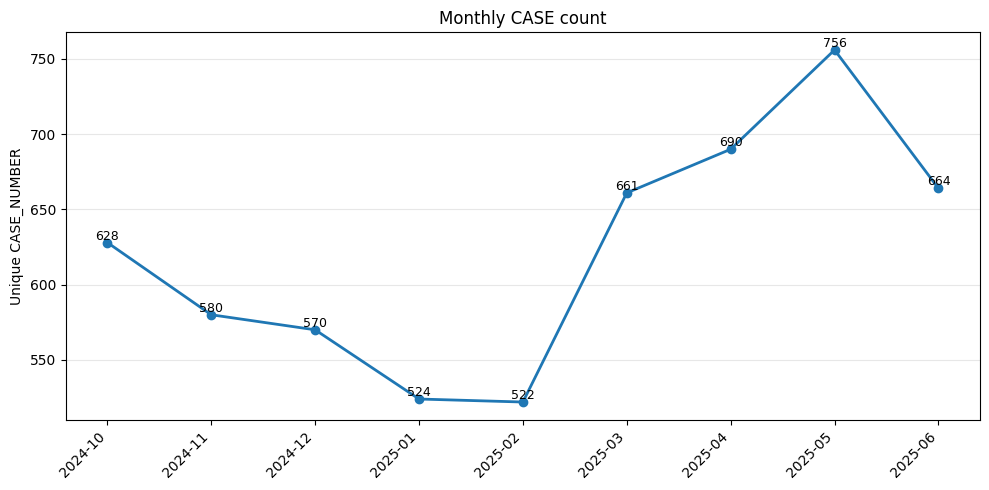

,CASE_COUNT
DECISION_MONTH,
2024-10,628
2024-11,580
2024-12,570
2025-01,524
2025-02,522
2025-03,661
2025-04,690
2025-05,756
2025-06,664


In [ ]:
# ApplicationsCount by month: data-related positions and change employer
plot_line_monthly_cases(data_chg_emp)

#### employer
- Compared to the overall data and all data-related positions, employers sponsoring H-1B transfers for data-related job changes are significantly more concentrated, with the top 40 employers accounting for over 30% of applications. 
- KFORCE, Capital One, and Pinterest are among the employers significantly more frequent than the overall number.

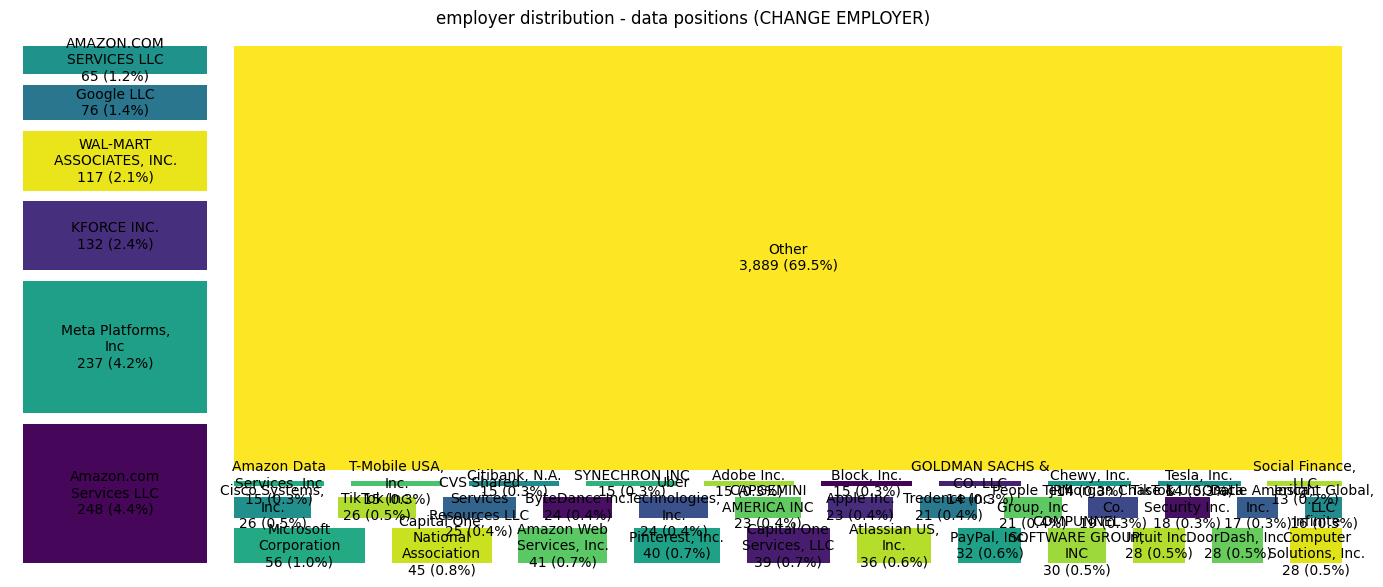

,count,pct
EMPLOYER_NAME,,
Amazon.com Services LLC,248,4.4
"Meta Platforms, Inc",237,4.2
KFORCE INC.,132,2.4
"WAL-MART ASSOCIATES, INC.",117,2.1
Google LLC,76,1.4
AMAZON.COM SERVICES LLC,65,1.2
Microsoft Corporation,56,1.0
"Capital One, National Association",45,0.8
"Amazon Web Services, Inc.",41,0.7


In [ ]:
# employer distribution: data-related positions and change employer
plot_treemap_from_series(data_chg_emp["EMPLOYER_NAME"], 
                         top_n=40, title="employer distribution - data positions (CHANGE EMPLOYER)")

#### employer state
- Looking at the distribution of employers' states for H1B transfers in the data field, the highest percentages are in California (28.8%), Washington (8.5%), Texas (8.3%), New York (8.1%), and New Jersey (6.9%). 
- California is significantly higher than both the overall number of data jobs and the total number of data jobs.

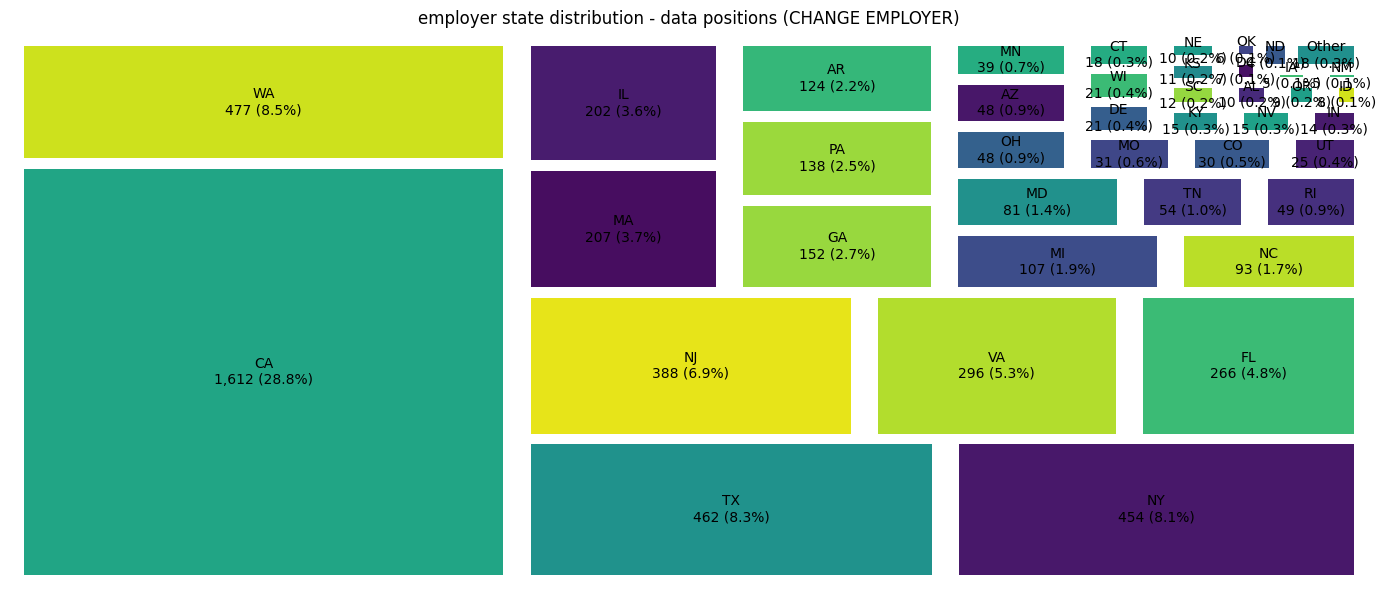

,count,pct
EMPLOYER_STATE,,
CA,1612,28.8
WA,477,8.5
TX,462,8.3
NY,454,8.1
NJ,388,6.9
VA,296,5.3
FL,266,4.8
MA,207,3.7
IL,202,3.6


In [ ]:
# employer state distribution: data-related positions and change employer
plot_treemap_from_series(data_chg_emp["EMPLOYER_STATE"], 
                               top_n=40, title="employer state distribution - data positions (CHANGE EMPLOYER)")

#### worksite state
Looking at the distribution of the states where beneficiaries of data-related and H1b transfer jobs actually work, the rankings roughly align with the employers' states, but Texas is significantly higher, while California and New Jersey are lower: California 23.8%, Texas 14.2%, New York 9.8%, Washington 9.9%, and New Jersey 5.5%.

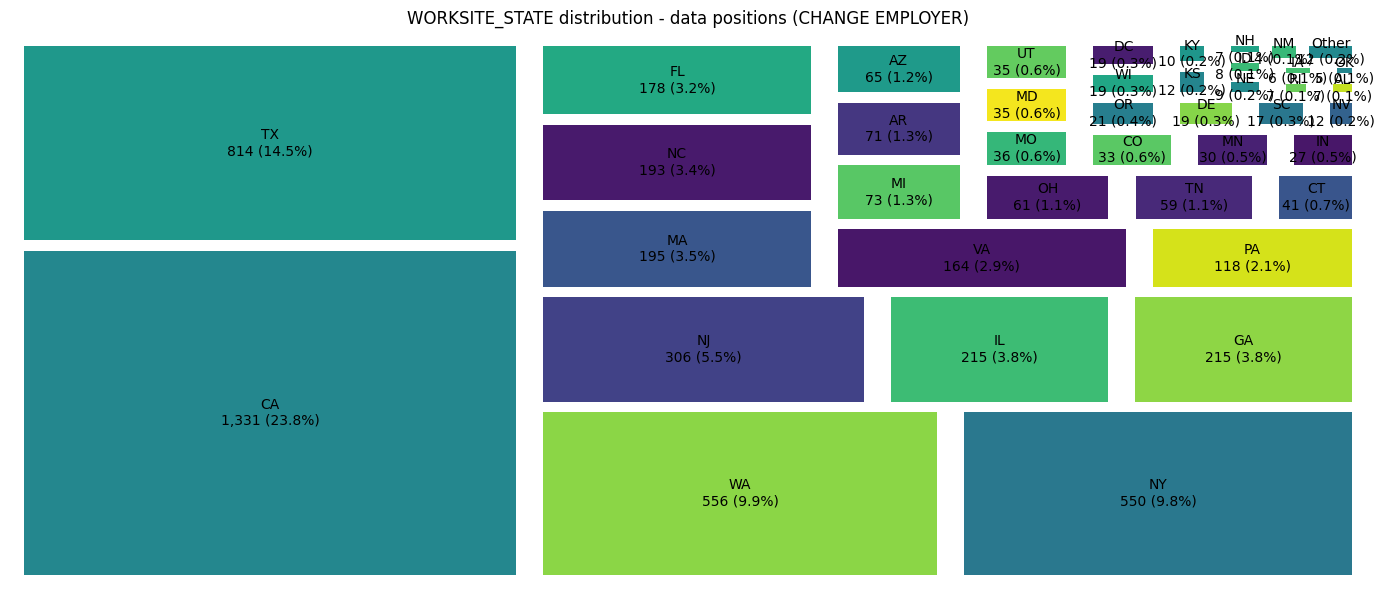

,count,pct
WORKSITE_STATE,,
CA,1331,23.8
TX,814,14.5
WA,556,9.9
NY,550,9.8
NJ,306,5.5
IL,215,3.8
GA,215,3.8
MA,195,3.5
NC,193,3.4


In [ ]:
# worksite state distribution: data-related positions and change employer
plot_treemap_from_series(data_chg_emp["WORKSITE_STATE"], 
                               top_n=40, title="WORKSITE_STATE distribution - data positions (CHANGE EMPLOYER)")

#### wage by title
Among H1b transfer applications, looking at the salary distribution for the three data positions, data scientists still have the highest median salary at 149K, while data analysts have the lowest at 114K, and business analysts at 116K. All three are higher than the median salary for their respective positions within the overall data category, especially data scientists and data analysts.

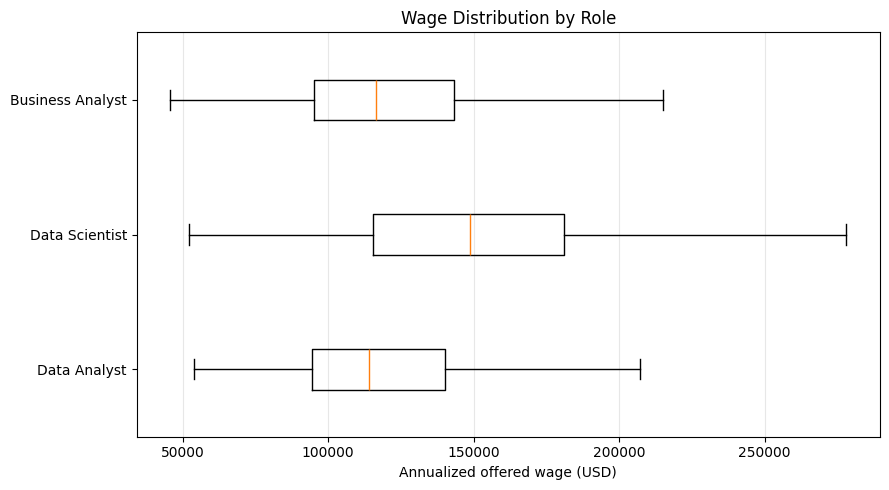

,Data Analyst,Data Scientist,Business Analyst
percentile,,,
0,54038.0,52042.0,45802.0
10,81557.0,92040.0,82713.2
20,92040.0,110739.0,92000.0
30,99700.0,120000.0,100000.0
40,106645.6,135000.0,110000.0
50,113974.5,148699.0,116480.0
60,123262.4,160000.0,125819.0
70,134493.0,175000.0,139268.4
80,145000.0,190000.0,150000.0


In [27]:
# Calculate the Wage Distribution for the three job types: da, ds, and ba
groups = role_wage_arrays(data_chg_emp, wage_col="OFFERED_WAGE_ANNUAL_USD")
plot_box_horizontal_from_groups(groups, title="Wage Distribution by Role")
tbl_deciles = role_deciles_table(data_chg_emp, wage_col="OFFERED_WAGE_ANNUAL_USD", step=0.10)
display(tbl_deciles)